**Business** **Problem**

Subscription companies lose revenue due to fraud such as:


*   fake accounts
*   free trail abuse
*   refund abuse
*   stolen credit cards

These behaviors inflate user metrics and create finacial losses.
Industry research suggests fraud and policy abuse can cost compaines over 2% of annual revenue. ([PYMNTS Fraud Report](https://www.pymnts.com/wp-content/uploads/2021/11/PYMNTS-Beyond-eCommerce-Fraud-November-2021.pdf))

For a subscription platform with:
1,000 users and $30/month subscription:

Potential fraud impact:
*   3% fraud rate = 3,000 accounts
*   3,000 x $30 = $90,0000 monthly loss

This project analyzes a simulated subscription dataset to identify patterns associated with fraudulent behavior and proposed risk mitigation strategies.




**Hypothesis**

Fraudulent users may exhibit may exhibit the following patterns:


1.   Multiple accounts created from the same device.
2.   High refund frequency.
1.   Repeated use of free trials.
2.   Subscriptions network activity such as VPN or cloud hosting providers.
1.   Higher chargeback rates.







In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print(os.listdir())
df = pd.read_csv("subscription_fraud_dataset.csv")

df.head()

['.config', 'subscription_fraud_dataset.csv', 'drive', 'sample_data']


,transaction_id,user_id,signup_date,account_age_days,device_id,datr_token,ssl_fingerprint,accounts_per_device,high_device_reuse_flag,ip_address,...,subscription_plan,trial_used_before,payment_status,refund_count_90d,refunded_flag,chargeback_flag,risk_score,review_bucket,fraud_type,fraud_label
0,TXN_00522,USR_00522,2025-04-02,333,DVC_032EBF5B32,DATR_8aea82b2edc84ae4,TLS_772_4865-49196_firefox_linux,1,0,22.243.25.43,...,monthly,0,refunded,0,1,0,0,low_risk,legit,0
1,TXN_00738,USR_00738,2025-03-28,338,DVC_CE07500BE3,DATR_7f29fcc291b347aa,TLS_771_4865-4866-4867_chrome_win,1,0,210.36.228.149,...,monthly,0,refunded,0,1,0,0,low_risk,legit,0
2,TXN_00741,USR_00741,2026-01-15,45,DVC_11B28050FB,DATR_ebbe7b95bfab4638,TLS_771_4865-4866_safari_ios,1,0,253.131.104.217,...,annual,0,paid,0,0,0,0,low_risk,legit,0
3,TXN_00661,USR_00661,2025-09-03,179,DVC_9FBD5F9D8C,DATR_ddf5749cd72d408c,TLS_772_4865-4866-4867_edge_win,1,0,206.114.160.38,...,trial,0,paid,0,0,0,0,low_risk,legit,0
4,TXN_00412,USR_00412,2025-03-14,352,DVC_C4F358584B,DATR_5dd73ad2df434324,TLS_772_4865-49196_firefox_linux,1,0,187.1.243.180,...,monthly,0,failed,0,0,0,0,low_risk,legit,0


In [ ]:
import os
os.listdir()

['.config', 'subscription_fraud_dataset.csv', 'drive', 'sample_data']

In [ ]:
df.shape

(1000, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   transaction_id            1000 non-null   object
 1   user_id                   1000 non-null   object
 2   signup_date               1000 non-null   object
 3   account_age_days          1000 non-null   int64 
 4   device_id                 1000 non-null   object
 5   datr_token                1000 non-null   object
 6   ssl_fingerprint           1000 non-null   object
 7   accounts_per_device       1000 non-null   int64 
 8   high_device_reuse_flag    1000 non-null   int64 
 9   ip_address                1000 non-null   object
 10  asn                       1000 non-null   object
 11  asn_provider              1000 non-null   object
 12  asn_type                  1000 non-null   object
 13  non_residential_asn_flag  1000 non-null   int64 
 14  ip_country               

In [ ]:
df.describe()

,account_age_days,accounts_per_device,high_device_reuse_flag,non_residential_asn_flag,high_risk_country_flag,trial_used_before,refund_count_90d,refunded_flag,chargeback_flag,risk_score,fraud_label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,162.983000,1.910000,0.124000,0.126000,0.196000,0.142000,0.290000,0.149000,0.016000,12.660000,0.15000
std,116.162285,2.540542,0.329746,0.332015,0.397167,0.349225,0.757941,0.356267,0.125538,25.552443,0.35725
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,52.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,155.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,266.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.00000
max,365.000000,12.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,120.000000,1.00000


In [ ]:
df["fraud_label"].value_counts()

,count
fraud_label,
0,850
1,150


In [ ]:
df["fraud_label"].value_counts(normalize=True)

,proportion
fraud_label,
0,0.85
1,0.15


In [ ]:
device_analysis = df.groupby("accounts_per_device")["fraud_label"].mean()
device_analysis

,fraud_label
accounts_per_device,
1,0.02968
5,1.00000
6,1.00000
7,1.00000
8,1.00000
9,1.00000
11,1.00000
12,1.00000


In [ ]:
refund_analysis = df.groupby("refund_count_90d")["fraud_label"].mean()
refund_analysis

,fraud_label
refund_count_90d,
0,0.091463
1,0.275000
2,0.400000
3,1.000000
4,1.000000
5,1.000000


In [ ]:
asn_analysis = df.groupby("asn_type")["fraud_label"].mean()
asn_analysis

,fraud_label
asn_type,
cloud,1.00000
residential,0.02746
vpn,1.00000


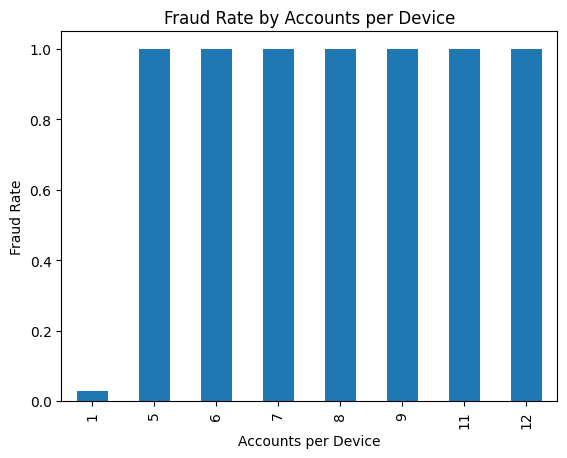

In [ ]:
import matplotlib.pyplot as plt

device_fraud = df.groupby("accounts_per_device")["fraud_label"].mean()

plt.figure()
device_fraud.plot(kind="bar")

plt.title("Fraud Rate by Accounts per Device")
plt.xlabel("Accounts per Device")
plt.ylabel("Fraud Rate")

plt.show()

### Interpretation

Fraud rates increase as the number of accounts associated with a single device rises.

This suggests that device reuse is a strong indicator of suspicious behavior, often linked to account farming or coordinated fraud activity. Monitoring devices with high account counts can help identify clusters of fraudulent users early.

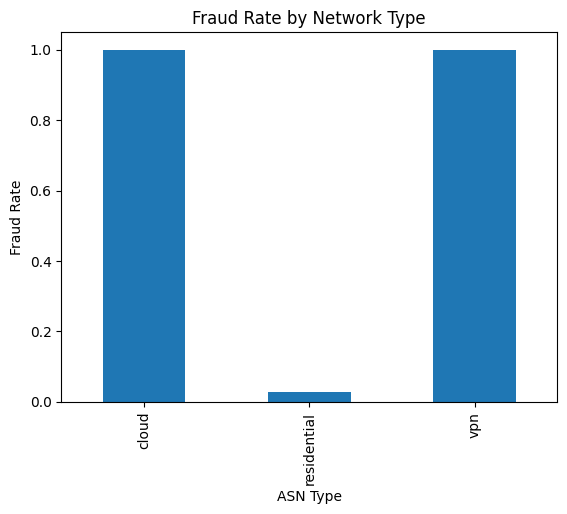

In [ ]:
asn_fraud = df.groupby("asn_type")["fraud_label"].mean()

plt.figure()
asn_fraud.plot(kind="bar")

plt.title("Fraud Rate by Network Type")
plt.xlabel("ASN Type")
plt.ylabel("Fraud Rate")

plt.show()

### Interpretation

Fraud rates are higher for users operating on cloud and VPN networks compared to residential networks.

This aligns with common fraud patterns, where attackers use hosted infrastructure or anonymization tools to create and manage accounts. Network type can therefore serve as a valuable input in risk scoring systems.

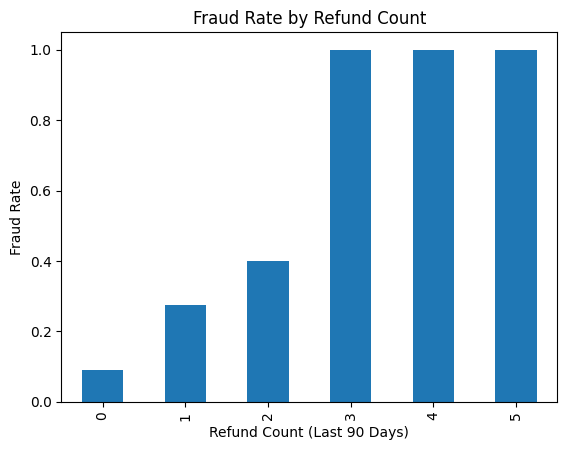

In [ ]:
refund_fraud = df.groupby("refund_count_90d")["fraud_label"].mean()

plt.figure()
refund_fraud.plot(kind="bar")

plt.title("Fraud Rate by Refund Count")
plt.xlabel("Refund Count (Last 90 Days)")
plt.ylabel("Fraud Rate")

plt.show()

### Interpretation

Fraud rates increase sharply as refund frequency rises, with users requesting multiple refunds showing the highest likelihood of fraud.

This indicates that refund behavior is a strong signal of abuse or exploitation of platform policies. Implementing thresholds for refund activity can help trigger earlier intervention and reduce financial loss.

## Fraud Risk Score Analysis

Fraud detection systems often assign a risk score to each user based on suspicious signals such as device reuse, refund behavior, network type, and account age.

This section evaluates how well the rule-based risk score separates fraudulent users from legitimate users.

In [ ]:
df.groupby("review_bucket")["fraud_label"].mean()

,fraud_label
review_bucket,
high_risk,1.000000
low_risk,0.009324
medium_risk,1.000000


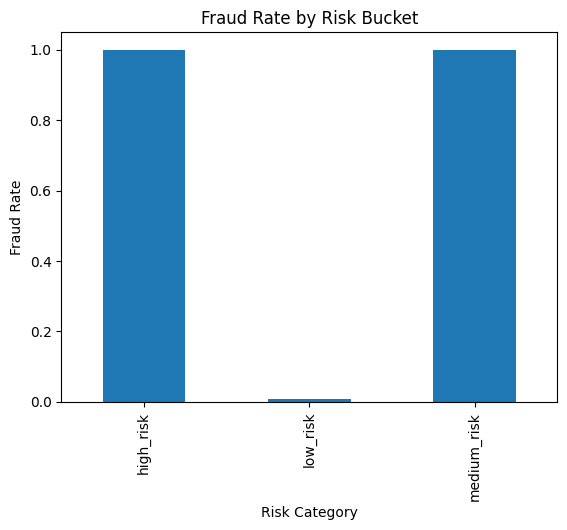

In [ ]:
import matplotlib.pyplot as plt

risk_analysis = df.groupby("review_bucket")["fraud_label"].mean()

plt.figure()
risk_analysis.plot(kind="bar")

plt.title("Fraud Rate by Risk Bucket")
plt.xlabel("Risk Category")
plt.ylabel("Fraud Rate")

plt.show()

### Interpretation

Fraud rates increase consistently from low-risk to high-risk buckets, indicating that the rule-based risk scoring system effectively separates fraudulent users from legitimate users.

This demonstrates that the scoring logic captures meaningful behavioral signals and can be used to prioritize manual review or automate enforcement decisions.

In [ ]:
funnel = df.groupby("payment_status")["fraud_label"].mean()

funnel

,fraud_label
payment_status,
chargeback,1.000000
failed,0.234483
paid,0.081159
refunded,0.295302


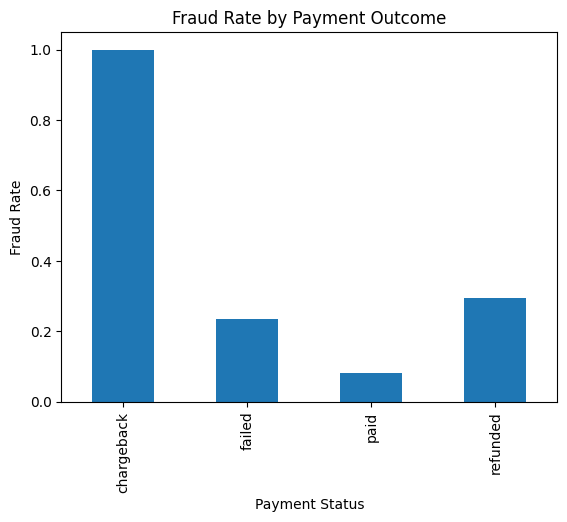

In [ ]:
plt.figure()
funnel.plot(kind="bar")

plt.title("Fraud Rate by Payment Outcome")
plt.xlabel("Payment Status")
plt.ylabel("Fraud Rate")

plt.show()

### Interpretation

Fraud is most concentrated in transactions associated with chargebacks and refunds, while successfully completed payments show significantly lower fraud rates.

This suggests that payment outcomes act as strong downstream indicators of fraudulent behavior. Leveraging these signals can improve feedback loops and strengthen fraud detection models over time.

## Estimated Financial Impact

Fraud detection is important because it protects revenue.

Assuming the average subscription price is $30 per month, we estimate the potential financial impact of fraudulent accounts in the dataset.

In [ ]:
avg_subscription = 30

fraud_users = df[df["fraud_label"] == 1].shape[0]

estimated_loss = fraud_users * avg_subscription

print("Estimated fraudulent accounts:", fraud_users)
print("Estimated monthly revenue impact: $", estimated_loss)

Estimated fraudulent accounts: 150
Estimated monthly revenue impact: $ 4500


### Interpretation

Even a relatively small number of fraudulent users results in meaningful revenue exposure.

This highlights the business importance of fraud detection systems, as reducing fraud rates can directly improve revenue retention and overall platform profitability.

## Fraud Prediction Model

To explore predictive modeling, a simple logistic regression model is trained to estimate the probability that a user is fraudulent based on behavioral and network signals.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
features = df[[
    "accounts_per_device",
    "refund_count_90d",
    "trial_used_before",
    "high_device_reuse_flag",
    "non_residential_asn_flag",
    "high_risk_country_flag",
    "chargeback_flag"
]]

target = df["fraud_label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
accuracy = model.score(X_test, y_test)

print("Model accuracy:", accuracy)

Model accuracy: 0.98


**Key** **Insights**


1.   Fraud rates increase significantly when multiple accounts share the same device.
2.   Refund heavy users are much more likely to be fraudulent.


1.   Fraud is more concentrated on cloud and VPN networks than residentail networks.
2.   Newer accounts show elevated fraud risk.

1.   The rule based risk scoring system effectively concentrestes fraud into higher risk buckets.
2.   Chargebacks and refund outcomes are strongly associated with fraud.







**Business** **Recommendations**

Based on the analysis, the company should consider the following fraud prevention strategies:

1. Limit account creation from heavily reused devices.
2. Flag users with 2 or more refunds in a 90-day period for manual review.
3. Apply higher risk scores to accounts using VPN or cloud-hosted infrastructure.
4. Add stricter review rules for newly created accounts showing suspicious behavior.
5. Use payment outcomes such as chargebacks and repeated refunds as downstream risk signals.
6. Continue evolving the rule-based system into a more advanced machine learning fraud model.

### Limitations and Future Work
This analysis uses simulated data designed to replicate realistic fraud patterns.

Future work could include:

- training more advanced machine learning models
- incorporating behavioral signals such as session velocity
- integrating real-world fraud datasets where available

## References

The following sources were used to inform assumptions about fraud patterns and industry practices:

- PYMNTS Fraud Report: https://www.pymnts.com/wp-content/uploads/2021/11/PYMNTS-Beyond-eCommerce-Fraud-November-2021.pdf  
- Stripe Fraud Prevention Overview: https://stripe.com/radar